# Topic 10 Lab: Monte Carlo vs. Temporal Difference on a Large GridWorld

We scale up the model-free prediction methods from Topics 8 (MC) and 9 (TD) to a **15x15 GridWorld with obstacles**,
and run a **comprehensive comparison**: many independent runs, mean $\pm$ std shadow bands, and a learning-rate sweep.

Setup: reward $-1$ per step, discount $\gamma = 0.9$ (keeps values bounded on the big grid), uniform random policy.
We measure each method's **RMS error against the true $V^\pi$** (computed exactly with dynamic programming, since we built the model).


## 1. The environment (15x15 grid with obstacles)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

N = 15
GOAL = (N - 1, N - 1)
GAMMA = 0.9
ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]   # up, down, left, right

# obstacles: walls the agent cannot enter
OBST = set()
for r in range(0, 11): OBST.add((r, 4))    # vertical wall, gap at bottom
for r in range(4, 15): OBST.add((r, 9))    # vertical wall, gap at top
for c in range(6, 13): OBST.add((7, c))    # horizontal wall
OBST.discard((0, 0)); OBST.discard(GOAL)

def free(r, c):
    return 0 <= r < N and 0 <= c < N and (r, c) not in OBST

FREE = [(r, c) for r in range(N) for c in range(N) if free(r, c)]
NONTERM = [s for s in FREE if s != GOAL]

def step(s, a):
    r, c = s
    dr, dc = ACTIONS[a]
    nr, nc = r + dr, c + dc
    if not free(nr, nc):            # wall/obstacle: stay in place
        nr, nc = r, c
    ns = (nr, nc)
    return ns, -1, (ns == GOAL)     # reward -1 per step

print(len(FREE), "free cells,", len(OBST), "obstacles")


197 free cells, 28 obstacles


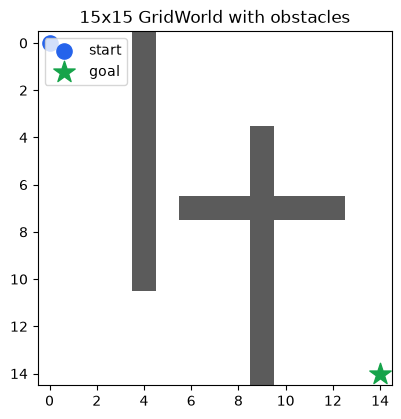

In [2]:
# visualize the grid
img = np.zeros((N, N))
for (r, c) in OBST: img[r, c] = 1
plt.figure(figsize=(4.6, 4.6))
plt.imshow(img, cmap="Greys", vmin=0, vmax=1.4)
plt.scatter([0], [0], s=120, color="#2563eb", label="start")
plt.scatter([GOAL[1]], [GOAL[0]], marker="*", s=260, color="#16a34a", label="goal")
plt.title("15x15 GridWorld with obstacles"); plt.legend(loc="upper left"); plt.show()


## 2. The true values (dynamic programming reference)

Because we *built* the model, we can compute the exact $V^\pi$ of the random policy by iterative policy evaluation.
This is only the yardstick, MC and TD below never use it.


In [3]:
def dp_reference():
    V = {s: 0.0 for s in FREE}
    for _ in range(20000):
        delta = 0.0
        for s in NONTERM:
            v = sum(0.25 * (r + GAMMA * V[step(s, a)[0]]) for a, r in
                    [(a, -1) for a in range(4)])
            delta = max(delta, abs(v - V[s])); V[s] = v
        if delta < 1e-9: break
    return V

V_TRUE = dp_reference()
true_vec = np.array([V_TRUE[s] for s in NONTERM])
def rms(Vd): return float(np.sqrt(np.mean((np.array([Vd[s] for s in NONTERM]) - true_vec) ** 2)))
print("true V range:", round(min(V_TRUE.values()), 2), "to", round(max(V_TRUE.values()), 2))


true V range: -10.0 to 0.0


## 3. Monte Carlo and TD, as learners

Both use **exploring starts** (each episode begins at a random free cell) so every state gets visited,
and a **constant learning rate** $\alpha$. MC averages the full episode return; TD updates every step with $R + \gamma V(s')$.


In [4]:
def run_mc(alpha, episodes, rng, max_steps=600):
    V = {s: 0.0 for s in FREE}; curve = np.empty(episodes)
    for k in range(episodes):
        s = NONTERM[rng.integers(len(NONTERM))]; traj = []; done = False; t = 0
        while not done and t < max_steps:
            a = rng.integers(4); ns, r, done = step(s, a); traj.append((s, r)); s = ns; t += 1
        G = 0.0
        for s_t, r_t in reversed(traj):          # walk backward to build the return
            G = r_t + GAMMA * G; V[s_t] += alpha * (G - V[s_t])
        curve[k] = rms(V)
    return curve

def run_td(alpha, episodes, rng, max_steps=600):
    V = {s: 0.0 for s in FREE}; curve = np.empty(episodes)
    for k in range(episodes):
        s = NONTERM[rng.integers(len(NONTERM))]; done = False; t = 0
        while not done and t < max_steps:
            a = rng.integers(4); ns, r, done = step(s, a)
            target = r + (0.0 if done else GAMMA * V[ns])   # bootstrap
            V[s] += alpha * (target - V[s]); s = ns; t += 1
        curve[k] = rms(V)
    return curve

def many_runs(fn, alpha, episodes, seeds):
    curves = np.stack([fn(alpha, episodes, np.random.default_rng(100 + i)) for i in range(seeds)])
    return curves.mean(0), curves.std(0)


## 4. Experiment 1, MC vs TD (mean $\pm$ std over many runs)

We run each method **25 times** and plot the average RMS-error curve with a shaded band of $\pm 1$ std.
MC drops fast but stays **noisier** (wider band); TD is **smoother** (tight band) and edges below MC by the end.


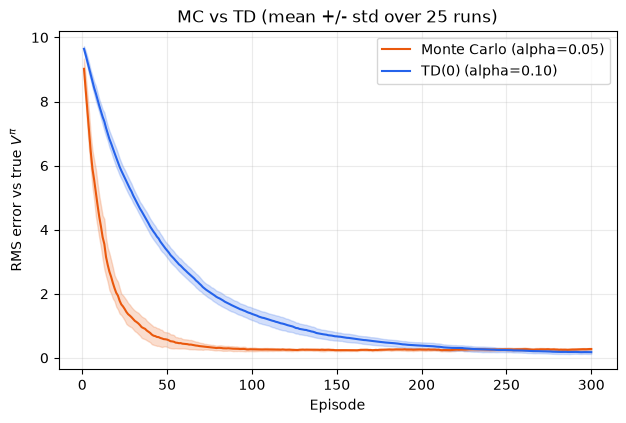

In [5]:
EP, SEEDS = 300, 25
mc_m, mc_s = many_runs(run_mc, 0.05, EP, SEEDS)
td_m, td_s = many_runs(run_td, 0.10, EP, SEEDS)

x = np.arange(1, EP + 1)
plt.figure(figsize=(7.2, 4.4))
plt.plot(x, mc_m, color="#ea580c", label="Monte Carlo (alpha=0.05)")
plt.fill_between(x, mc_m - mc_s, mc_m + mc_s, color="#ea580c", alpha=0.2)
plt.plot(x, td_m, color="#2563eb", label="TD(0) (alpha=0.10)")
plt.fill_between(x, td_m - td_s, td_m + td_s, color="#2563eb", alpha=0.2)
plt.xlabel("Episode"); plt.ylabel(r"RMS error vs true $V^\pi$")
plt.title(f"MC vs TD (mean +/- std over {SEEDS} runs)")
plt.legend(); plt.grid(alpha=0.25); plt.show()


## 5. Experiment 2, the effect of the learning rate $\alpha$

A **parameter sweep**: small $\alpha$ learns slowly but steadily; large $\alpha$ learns fast but is noisier.


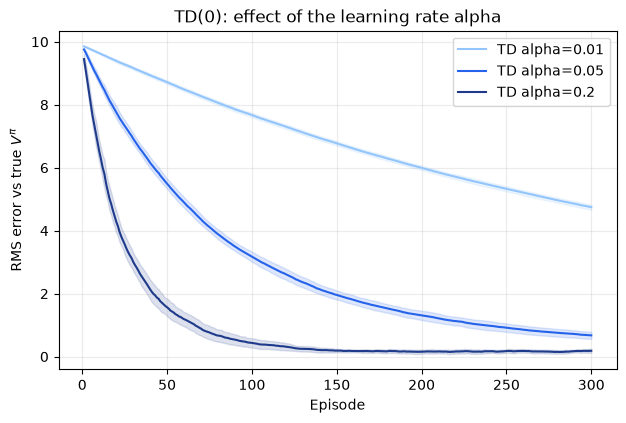

In [6]:
plt.figure(figsize=(7.2, 4.4))
for alpha, col in [(0.01, "#93c5fd"), (0.05, "#2563eb"), (0.2, "#1e3a8a")]:
    m, s = many_runs(run_td, alpha, EP, SEEDS)
    plt.plot(x, m, color=col, label=f"TD alpha={alpha}")
    plt.fill_between(x, m - s, m + s, color=col, alpha=0.15)
plt.xlabel("Episode"); plt.ylabel(r"RMS error vs true $V^\pi$")
plt.title("TD(0): effect of the learning rate alpha")
plt.legend(); plt.grid(alpha=0.25); plt.show()


## 6. Do the learned values look right?

Train each method longer and compare the value heatmaps to the DP truth, they should match.


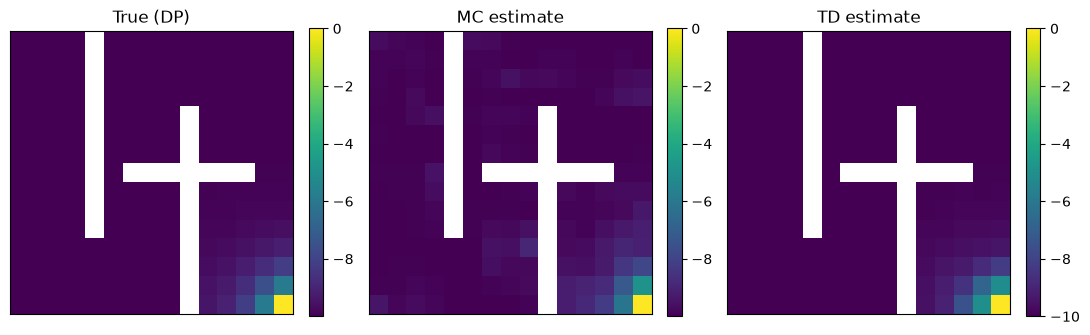

In [7]:
def train(fn_kind, alpha, episodes, rng, max_steps=600):
    V = {s: 0.0 for s in FREE}
    for _ in range(episodes):
        s = NONTERM[rng.integers(len(NONTERM))]; traj = []; done = False; t = 0
        while not done and t < max_steps:
            a = rng.integers(4); ns, r, done = step(s, a)
            if fn_kind == "td":
                target = r + (0.0 if done else GAMMA * V[ns]); V[s] += alpha * (target - V[s])
            else:
                traj.append((s, r))
            s = ns; t += 1
        if fn_kind == "mc":
            G = 0.0
            for s_t, r_t in reversed(traj):
                G = r_t + GAMMA * G; V[s_t] += alpha * (G - V[s_t])
    return V

def to_img(Vd):
    a = np.full((N, N), np.nan)
    for s, v in Vd.items(): a[s] = v
    return a

Vmc = train("mc", 0.05, 8000, np.random.default_rng(1))
Vtd = train("td", 0.10, 8000, np.random.default_rng(1))
fig, ax = plt.subplots(1, 3, figsize=(11, 3.6))
for a, (t, Vd) in zip(ax, [("True (DP)", V_TRUE), ("MC estimate", Vmc), ("TD estimate", Vtd)]):
    im = a.imshow(to_img(Vd), cmap="viridis"); a.set_title(t); a.set_xticks([]); a.set_yticks([])
    fig.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()


## 7. From values to a path: can we read off the optimal route?

A value function tempts us to walk the **optimal path** by greedy one-step lookahead, $a^\star(s)=\arg\max_a[R+\gamma V(s')]$. There is a catch.

Because we know the model we can run **value iteration** (the Bellman *optimality* equation) to get the optimal values $V^\ast$; greedy lookahead on $V^\ast$ traces the true shortest route around the walls. But the MC/TD values in this lab estimate $V^\pi$ for the **random policy**: with $\gamma=0.9$ that surface **saturates to the $-10$ floor** far from the goal (no gradient, no path signal). Reading an optimal path out of *experience* is the job of **control** (next topics).

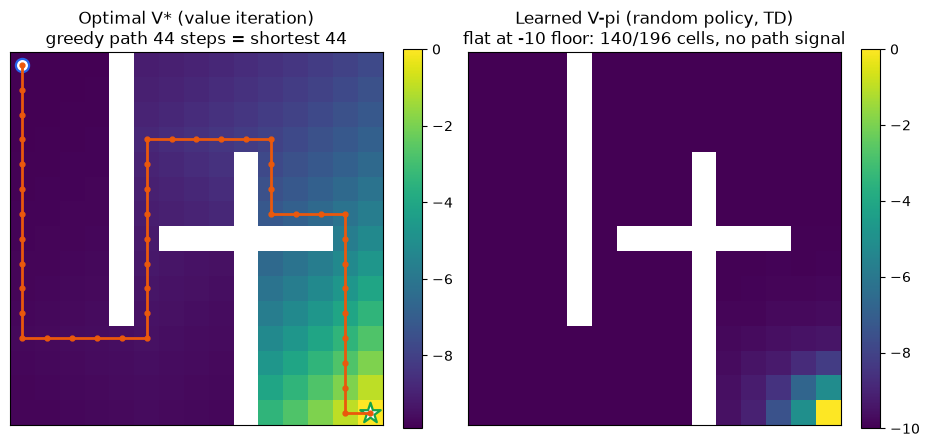

greedy on V*: 44 steps | BFS shortest: 44 | V-pi flat cells: 140


In [8]:
from collections import deque

def value_iteration():
    V = {s: 0.0 for s in FREE}
    for _ in range(5000):
        d = 0.0
        for s in NONTERM:
            v = max(step(s, a)[1] + GAMMA * V[step(s, a)[0]] for a in range(4))
            d = max(d, abs(v - V[s])); V[s] = v
        if d < 1e-12: break
    return V

def bfs_shortest():
    dist = {GOAL: 0}; q = deque([GOAL])
    while q:
        s = q.popleft()
        for dr, dc in ACTIONS:
            nb = (s[0] - dr, s[1] - dc)
            if free(*nb) and nb not in dist:
                dist[nb] = dist[s] + 1; q.append(nb)
    return dist[(0, 0)]

def greedy_path(V, max_steps=400):
    s = (0, 0); path = [s]; seen = {s}
    for _ in range(max_steps):
        if s == GOAL: break
        cand = sorted(((step(s, a)[1] + GAMMA * V[step(s, a)[0]], step(s, a)[0])
                       for a in range(4)), key=lambda t: -t[0])
        nxt = next((ns for _, ns in cand if ns != s and ns not in seen), cand[0][1])
        if nxt == s: break
        s = nxt; seen.add(s); path.append(s)
    return path

Vstar = value_iteration(); SHORT = bfs_shortest()
p = greedy_path(Vstar); xs = [c for _, c in p]; ys = [r for r, _ in p]
flat = sum(abs(V_TRUE[s] + 10) < 1e-3 for s in NONTERM)

fig, ax = plt.subplots(1, 2, figsize=(9.4, 4.4))
im = ax[0].imshow(to_img(Vstar), cmap='viridis')
ax[0].plot(xs, ys, '-o', color='#ea580c', ms=3.5, lw=2)
ax[0].scatter([0], [0], marker='o', s=90, color='w', edgecolors='#2563eb', linewidths=1.6)
ax[0].scatter([GOAL[1]], [GOAL[0]], marker='*', s=240, color='w', edgecolors='#16a34a', linewidths=1.6)
ax[0].set_title(f'Optimal V* (value iteration)\ngreedy path {len(p)-1} steps = shortest {SHORT}')
ax[0].set_xticks([]); ax[0].set_yticks([]); fig.colorbar(im, ax=ax[0], fraction=0.046)
im = ax[1].imshow(to_img(Vtd), cmap='viridis')
ax[1].set_title(f'Learned V-pi (random policy, TD)\nflat at -10 floor: {flat}/{len(NONTERM)} cells, no path signal')
ax[1].set_xticks([]); ax[1].set_yticks([]); fig.colorbar(im, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()
print('greedy on V*:', len(p) - 1, 'steps | BFS shortest:', SHORT, '| V-pi flat cells:', flat)

## Assignment 10

**Build your own GridWorld and repeat this study.**

1. Design a different environment: change the **size**, the **obstacle layout**, and/or the **goal**. Keep it solvable.
2. Apply **both MC and TD** prediction for the random policy, exactly as above.
3. Run each method **many times** and report the mean curve with a **std (shadow) band**.
4. Do a **parameter study**: vary $\alpha$ (and optionally $\gamma$) and show how convergence changes.
5. Show a **value heatmap** (true vs MC vs TD).

Submit a **PDF report** in the **same format as our lecture notes and slides**: figures (with shaded mean $\pm$ std),
tables of final errors, and a short discussion of what you observed (bias vs variance, effect of $\alpha$, MC vs TD).
